In [1]:
%load_ext autoreload
%autoreload 2
import pprint, json, math, os, sys, camelot
# sys.path.append(os.path.abspath(dir_path))
import subprocess

import fitz, pdfplumber, ocrmypdf, pprint
import pandas as pd
import numpy as np
from collections import defaultdict
from app.parse_table import TableParser
from app.utils import Helper, PDFTableExtractor

helper = Helper()

HANDLER OF TABLE EXTRACTOR

In [ ]:
#new code
from app.utils import Helper
from table_fetch import FetchTable
jsn_path = r"annot.json"
helper = Helper()
configs = helper.load_json(jsn_path)


pdf_path = r"AVIVA.pdf"

df = FetchTable.new_handler(
    pdf_path,
    configs
)

df.to_csv("SAMPLEEEEEEEEE.csv", index=None)


In [ ]:
#new code sheet wise
import pandas as pd
from app.utils import Helper
from table_fetch import FetchTable
from pathlib import Path
jsn_path = r"annot.json5"
helper = Helper()
configs = helper.load_json5(jsn_path)

pdf_path = r"HSBC.pdf"
# print(f"CONFIG: {configs}")

def determine_numeric_cols(df:pd.DataFrame, threshold = 0.6)->list:

    is_numeric_like = lambda col: (lambda s: sum(c in "0123456789,.- " for c in s) / len(s) if len(s) else 0)(" ".join(col.astype(str)))
    
    numeric_cols = []
    df_cols = df.columns
    # print(df_cols)
    for col in df_cols:
        ratio = is_numeric_like(df[col])
        if ratio>=threshold:
            numeric_cols.append(col)
    return numeric_cols

filter_numeric = lambda x: "".join(c for c in str(x) if c in "0123456789.,-")
encode_utf = lambda text: str(text).encode('latin1', errors='ignore').decode('utf-8', errors='ignore')


#currently using automatic handler
content, debug_c, debug_r, items = FetchTable.automate_handler(pdf_path,configs)


content.to_excel(pdf_path.replace(".pdf",".xlsx"), index = None)


xls_path = pdf_path.replace(".pdf",".xlsx")

with pd.ExcelWriter(xls_path, engine="openpyxl") as writer:
    for x, data in content.items():
        for frame in data:
            pgn = frame["page"]
            tbl = frame["table"]
            df = frame["df"]
            sheet_name = f"page_{pgn}_{tbl}"
            df.to_excel(writer, sheet_name=sheet_name, index=False)


In [24]:
import pandas as pd
from app.utils import Helper
from table_ft import FetchTable
jsn_path = r"annot.json5"
helper = Helper()
configs = helper.load_json5(jsn_path)

pdf_path = r"GODFATHER.pdf"
xls_path = pdf_path.replace(".pdf",".xlsx")
# print(f"CONFIG: {configs}")

content = FetchTable.excel_handler(pdf_path,configs)



CONFIG DUDE: {'page_number': 1, 'table_rect': [24.58, 150.14, 570.7, 669.91], 'columns': [1, 2]}
PAGE NO: 0, TBLE: 0
BBOX: [24.58, 150.14, 570.7, 669.91]
THE ITEMS:[{'x0': 360.3870849609375, 'y0': 166.9467315673828, 'x1': 387.09783935546875, 'y1': 173.0211181640625, 'text': 'Quarter', 'x_center': 373.7424621582031, 'y_center': 169.98392486572266, 'height': 6.0743865966796875}, {'x0': 388.74139404296875, 'y0': 166.94610595703125, 'x1': 410.1099853515625, 'y1': 173.020263671875, 'text': 'ended', 'x_center': 399.4256896972656, 'y_center': 169.98318481445312, 'height': 6.07415771484375}, {'x0': 413.39727783203125, 'y0': 167.755615234375, 'x1': 421.2051086425781, 'y1': 173.01959228515625, 'text': 'on', 'x_center': 417.3011932373047, 'y_center': 170.38760375976562, 'height': 5.26397705078125}, {'x0': 498.0484924316406, 'y0': 166.94757080078125, 'x1': 513.2537231445312, 'y1': 173.02284240722656, 'text': 'Year', 'x_center': 505.65110778808594, 'y_center': 169.9852066040039, 'height': 6.0752716

In [22]:
with pd.ExcelWriter(xls_path, engine="openpyxl") as writer:
    for x, data in content.items():
        for frame in data:
            pgn = frame["page"]
            tbl = frame["table"]
            df = frame["df"]
            sheet_name = f"page_{pgn}_{tbl}"
            df.to_excel(writer, sheet_name=sheet_name, index=False)

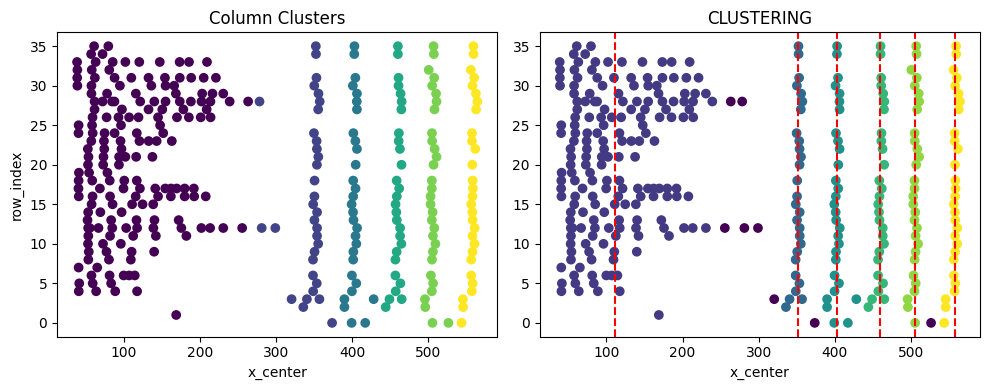

Detected centers [np.float64(111.68828122629284), np.float64(351.6550064086914), np.float64(403.60338287353517), np.float64(460.1189090183803), np.float64(505.6515736897787), np.float64(557.6412900727371)]


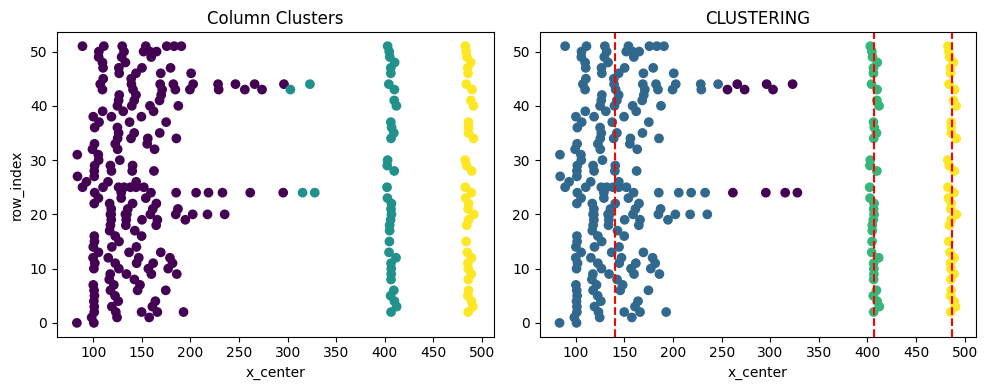

Detected centers [np.float64(140.4003857405728), np.float64(406.6627011685758), np.float64(486.48780534074115)]


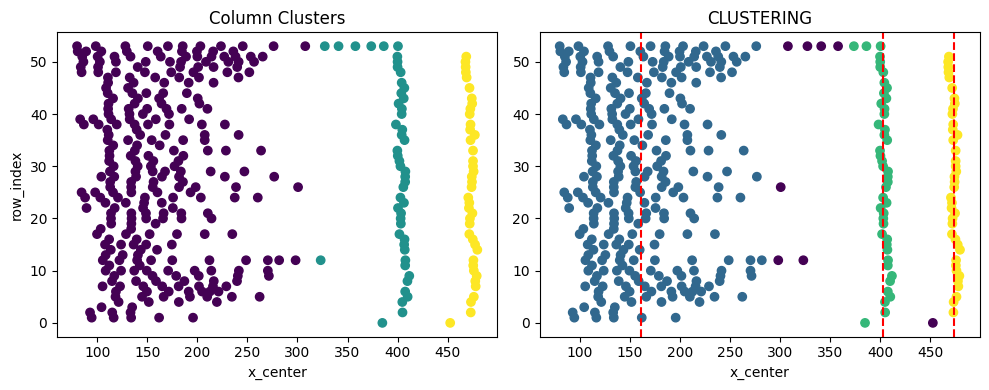

Detected centers [np.float64(161.120258621691), np.float64(402.9812767876519), np.float64(473.7916709899902)]


In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN

def plot_from_debug_cols(debug_cols, eps=15, min_samples=5):

    xs = []
    ys = []
    col_labels = []

    for col_idx, rows in debug_cols.items():
        for row in rows:
            r_idx = row["row_index"]

            for item in row["items"]:
                xs.append(item["x_center"])
                ys.append(r_idx)
                col_labels.append(col_idx)  # YOUR assigned column

    xs = np.array(xs)
    ys = np.array(ys)

    # ---- DBSCAN ----
    X = xs.reshape(-1, 1)
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    db_labels = db.labels_

    # ---- Plot ----
    plt.figure(figsize=(10, 4))


    plt.subplot(1, 2, 1)
    plt.scatter(xs, ys, c=col_labels)
    plt.title("Column Clusters")
    plt.xlabel("x_center")
    plt.ylabel("row_index")


    plt.subplot(1, 2, 2)
    plt.scatter(xs, ys, c=db_labels)
    plt.title("CLUSTERING")
    plt.xlabel("x_center")

    # ---- Compute cluster centers ----
    clusters = {}
    for x, label in zip(xs, db_labels):
        if label == -1:
            continue
        clusters.setdefault(label, []).append(x)

    centers = sorted(np.mean(v) for v in clusters.values())

   
    for c in centers:
        plt.axvline(c, linestyle="--", linewidth=1.5, color="red")

    plt.tight_layout()
    plt.show()

    print("Detected centers", centers)


for x, data in content.items():
    for frame in data:
        # pgn = frame["page"]
        # tbl = frame["table"]
        # df = frame["df"]
        # sheet_name = f"page_{pgn}_{tbl}"
        
        debug_c = frame["debug_c"]
        
        plot_from_debug_cols(debug_c)

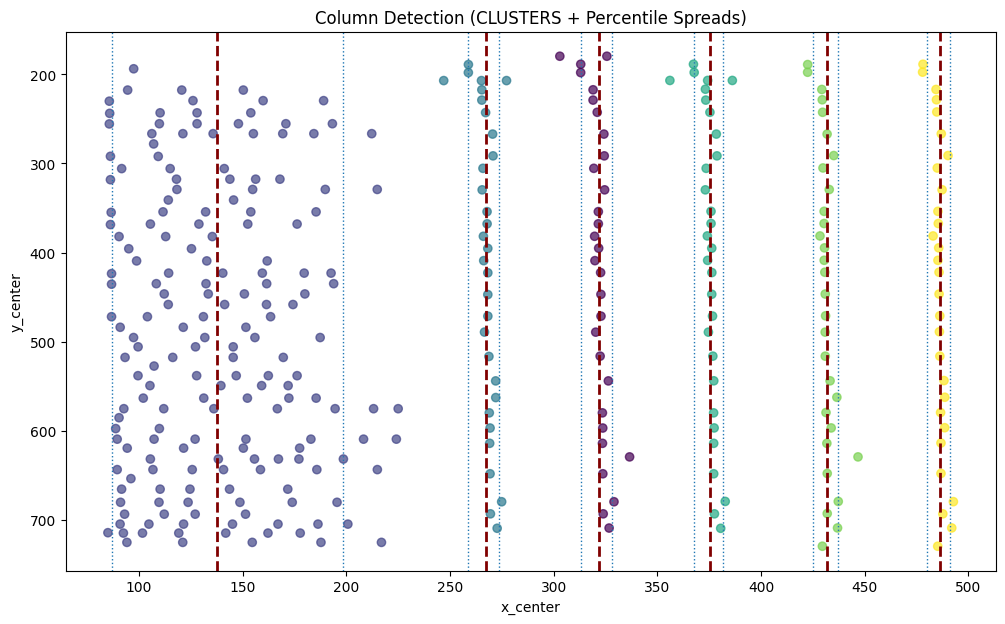

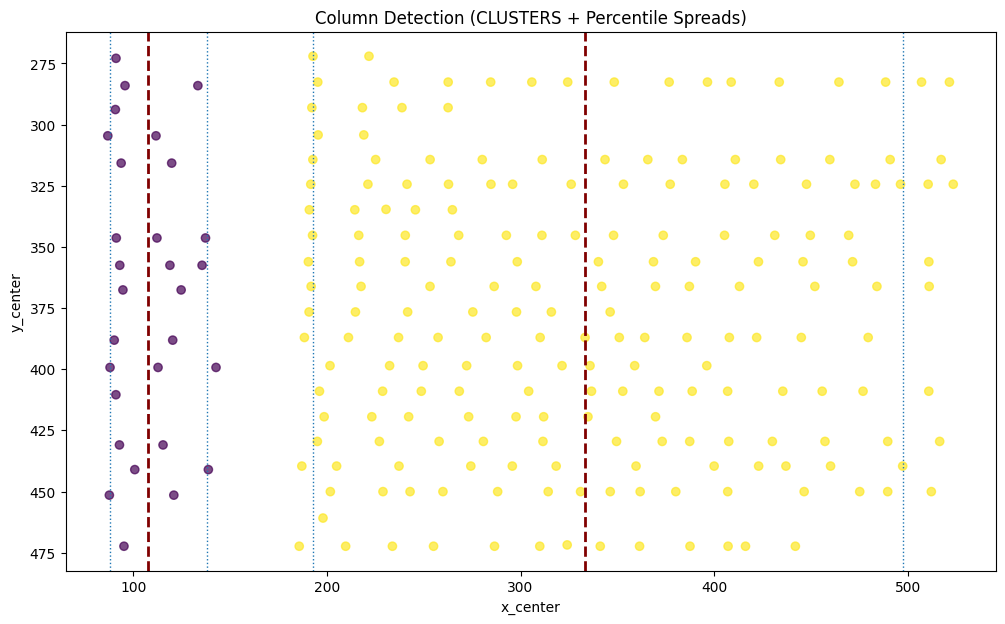

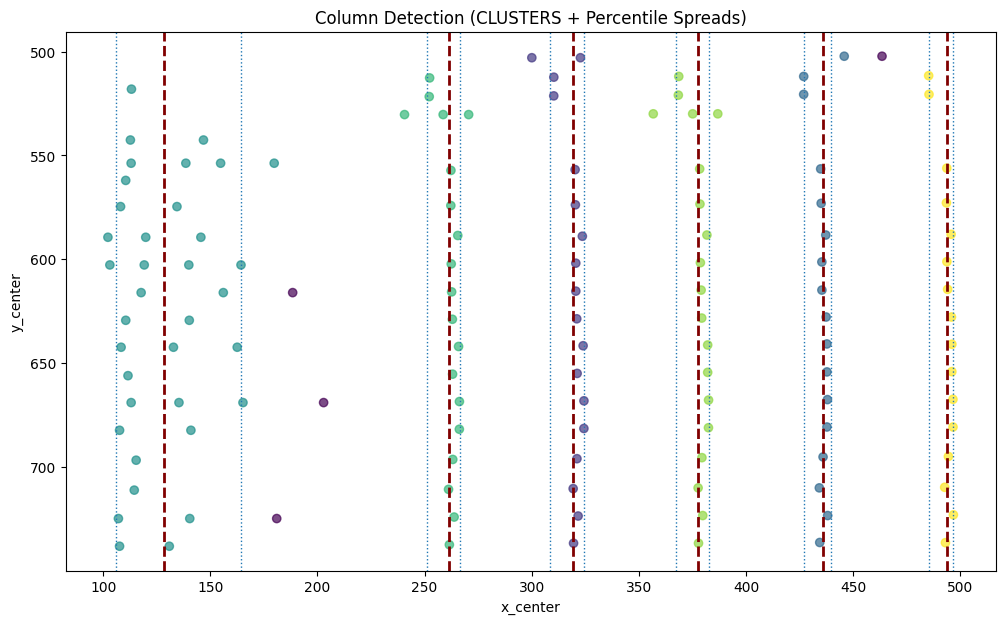

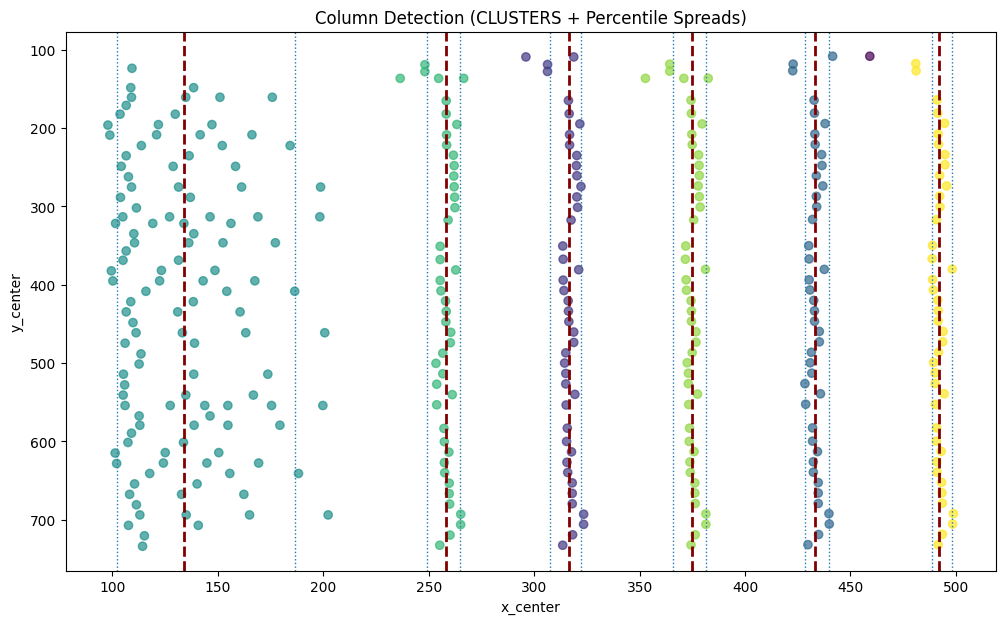

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

def plot_spreads_from_items(items, eps=15, min_samples=5):

    # ---- Extract data ----
    xs = np.array([i["x_center"] for i in items])
    ys = np.array([i["y_center"] for i in items])

    # ---- DBSCAN ----
    X = xs.reshape(-1, 1)
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    labels = db.labels_

    # ---- Build clusters ----
    clusters = {}
    for x, label in zip(xs, labels):
        if label == -1:
            continue
        clusters.setdefault(label, []).append(x)

    # ---- Compute percentile spreads ----
    col_spans = []

    for label, col_xs in clusters.items():
        col_xs = np.array(col_xs)

        left = np.percentile(col_xs, 5)
        right = np.percentile(col_xs, 95)
        center = np.mean(col_xs)

        col_spans.append({
            "center": center,
            "left": left,
            "right": right
        })

    # sort for clean visualization
    col_spans = sorted(col_spans, key=lambda x: x["center"])

    # ---- Plot ----
    plt.figure(figsize=(12, 7))

    # scatter points colored by DBSCAN cluster
    plt.scatter(xs, ys, c=labels, alpha=0.7)

    # ---- draw spreads ----
    for col in col_spans:
        # center line
        plt.axvline(col["center"], linestyle="--", linewidth=2, color = "maroon")

        # spread boundaries
        plt.axvline(col["left"], linestyle=":", linewidth=1)
        plt.axvline(col["right"], linestyle=":", linewidth=1)

    plt.title("Column Detection (CLUSTERS + Percentile Spreads)")
    plt.xlabel("x_center")
    plt.ylabel("y_center")

    # IMPORTANT: invert to match PDF coordinate system
    plt.gca().invert_yaxis()

    plt.show()

    return col_spans


for x, data in content.items():
    for frame in data:     
        debug_c = frame["items"]
        plot_spreads_from_items(debug_c)

In [ ]:
from table_fetch1 import FetchTable
import pandas as pd
from app.utils import Helper
pth = r"C:\Users\kaustubh.keny\Projects\OFFICE PROJECTS\rep_fsparse\config\annot.json5"
helper = Helper()
configs = helper.load_json5(pth)

path = r"searchable_output.pdf"
# path = r"ZEE.pdf"

df, mapping = FetchTable.bhonsle_handler(path,configs)
df.to_excel(path.replace(".pdf",".xlsx"), index=False)

# with pd.ExcelWriter(xls_path, engine="openpyxl") as writer:
#     for page_n, df in content.items():
#         sheet_name = f"Page_{page_n}"
        
#         df.to_excel(writer, sheet_name=sheet_name, index=False)



In [ ]:
import fitz  # PyMuPDF
import easyocr
import cv2
import numpy as np

pdf_path = r"C:\Users\kaustubh.keny\Downloads\C_MAST.pdf"
doc = fitz.open(pdf_path)
n_doc = fitz.open()

for idx in range(0,doc.page_count):
    # print(f"Page_{idx}")
    page = doc[idx]
    pix = page.get_pixmap()
    img_path = f"output_page_{idx}.png"
    pix.save(img_path)
    
    reader = easyocr.Reader(['en'])
    ocr_results = reader.readtext(
        img_path,
        decoder="beamsearch",
        text_threshold=.5
        )
    
    
    n_page = n_doc.new_page(width=page.rect.width, height=page.rect.height)
    
    for bbox, text, conf in ocr_results:
        # Take top-left point of bounding box
        x, y = bbox[0]

        # Adjust Y slightly
        # y += 10

        n_page.insert_text(
            (x, y),
            text,
            fontsize=10,
            color=(0, 0, 0)
        )

n_doc.save("WE_TRIED.pdf")
    

In [ ]:
import fitz  # PyMuPDF
import easyocr
import cv2
import numpy as np

# Load image
img_path = "m1.png"
img = cv2.imread(img_path)
h, w, _ = img.shape

# OCR
reader = easyocr.Reader(['en'])
result = reader.readtext(img_path)

# Create PDF
doc = fitz.open()
page = doc.new_page(width=w, height=h)

# Add image as background (optional but recommended)
pix = fitz.Pixmap(img_path)
page.insert_image(fitz.Rect(0, 0, w, h), pixmap=pix)

# Overlay OCR text
for bbox, text, prob in result:
    pts = np.array(bbox)

    x = int(pts[:,0].min())
    y = int(pts[:,1].min())

    # IMPORTANT: fitz uses bottom-left origin
    y_pdf = h - y

    page.insert_text(
        (x, y_pdf),
        text,
        fontsize=8,
        color=(0, 0, 0)
    )

# Save PDF
doc.save("output.pdf")

print("✅ OCR PDF created!")